# Spam classifier

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as opt 
import sklearn.metrics
from sklearn.utils  import shuffle


In [2]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [3]:

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## data processing (from tutorial)

importing csv and word2indexing

In [ ]:
# from sklearn.utils import shuffle


# df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
# df.head()
# # rename columns to something better
# df.columns = ['labels', 'data']
# # create binary labels
# df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1})

# df_train, df_test = train_test_split(df, test_size=0.33)
# df_train.shape, df_test.shape


# # 0 = padding
# idx = 1
# word2idx = {'<PAD>': 0}
# # you could always use gensim or spacy for tokenization,
# # but let's keep it simple!
# for i, row in df_train.iterrows():
#   tokens = row['data'].lower().split() # simple tokenization
#   for token in tokens:
#     if token not in word2idx:
#       word2idx[token] = idx
#       idx += 1

# word2idx
# len(word2idx)

# # convert data into word indices
# # note: could have done this on the fly earlier
# train_sentences_as_int = []
# for i, row in df_train.iterrows():
#   tokens = row['data'].lower().split()
#   sentence_as_int = [word2idx[token] for token in tokens]
#   train_sentences_as_int.append(sentence_as_int)


# test_sentences_as_int = []
# for i, row in df_test.iterrows():
#   tokens = row['data'].lower().split()
#   sentence_as_int = [word2idx[token] for token in tokens if token in word2idx]
#   test_sentences_as_int.append(sentence_as_int)


# len(train_sentences_as_int), len(test_sentences_as_int) 



creating data generators


In [ ]:
# def data_generator(X, y, batch_size=32):
#   X, y = shuffle(X, y)
#   n_batches = int(np.ceil(len(y) / batch_size))
#   for i in range(n_batches):
#     end = min((i + 1) * batch_size, len(y))

#     X_batch = X[i * batch_size:end]
#     y_batch = y[i * batch_size:end]

#     # pad X_batch to be N x T
#     max_len = np.max([len(x) for x in X_batch])
#     for j in range(len(X_batch)):
#       x = X_batch[j]
#       pad = [0] * (max_len - len(x))
#       X_batch[j] = pad + x
    
#     # convert to tensor
#     X_batch = torch.from_numpy(np.array(X_batch)).long()
#     y_batch = torch.from_numpy(np.array(y_batch)).long()
    
#     yield X_batch, y_batch




example of usage

In [5]:
# for inputs, targets in data_generator(train_sentences_as_int, df_train.b_labels):
#   print("inputs", inputs, "shape:", inputs.shape)
#   print("targets", targets, "shape:", targets.shape)
#   break

## data processing (mine)

In [6]:
df['spam'] = df['v1'].map({'ham': 0, 'spam': 1})
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4','v1'])
df.columns = ['data', 'spam']
df.head()

,data,spam
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [7]:
corpus,y = df['data'].values,df['spam'].values

In [8]:
class Word2index:
    def __init__(self):
        self.PADDING = 0 
        self.word2idx ={'<pad>':self.PADDING,'<unknown>':1}
        self.current_index = 2
        

    def add(self,word):
        if  word.lower() not in self.word2idx:
            self.word2idx[word.lower()] = self.current_index
            self.current_index += 1
        return self.get_index_from_word(word.lower())
    
    def get_index_from_word(self,word)->int:
        if  word.lower() in self.word2idx:
            return self.word2idx[word.lower()]
        
       
        return self.word2idx['<unknown>']
        

    def get_vocab_size(self):
        return len(self.word2idx)

    def make_reverse(self):
        self.idx2word = {}
        for word,i in self.word2idx.items():
            self.idx2word[i] = word
    
    def index_to_word(self,i)->str:
        if i in self.idx2word:
            return self.idx2word[i]
    



my data generator

In [9]:
class DataGenerator:
    def __init__(self,corpus,labels):
        self.word2indexDict = Word2index()
        self.__proccess_corpus__(corpus=corpus)
        self.y = labels

    def __proccess_corpus__(self,corpus):
        self.texts = []
        self.max_row_size = 0
        for text in corpus:
            text = str(text)

            text = re.sub('[^a-zA-Z0-9 ]+','',text)
            row = re.split(' ',text)
            self.max_row_size = np.max([self.max_row_size,len(row)])
            row = [x for x in row if x != '']
            self.texts.append(row)

    def train_test_split(self,test_percentage=0.25):

        
        X_train,X_test,self.y_train, self.y_test = train_test_split(self.texts,self.y,test_size=test_percentage)


        self.X_train = []
        for sample in X_train:
            sentence = []

            for word in sample:
                index = self.word2indexDict.add(word)
                assert index is not None and index == self.word2indexDict.get_index_from_word(word) and index >= 0
                sentence.append(index)
            self.X_train.append(sentence)
        self.word2indexDict.make_reverse()
        
        self.X_test = []
        for sample in X_test:
            sentence = []
            for word in sample:
                index = self.word2indexDict.get_index_from_word(word)
                assert index is not None and  index == self.word2indexDict.get_index_from_word(word) and index >= 0
                sentence.append(index)

            self.X_test.append(sentence)

      

    def  generate_helper(self,X,y,batch_size=32):
        num_batches = int(np.ceil(len(y)/batch_size))


        for i in range(num_batches):
            end = min(len(y),(i+1)*batch_size)
            X_batch = X[i*batch_size: end]
            y_batch = y[i*batch_size: end]

            for j in range(len(X_batch)):
                X_batch[j] = [self.word2indexDict.PADDING] * (self.max_row_size - len(X_batch[j])) + X_batch[j]

                    # convert to tensor
            y_batch = y_batch.reshape(-1,1)
            X_batch = torch.from_numpy(np.array(X_batch)).long()
            y_batch = torch.from_numpy(np.array(y_batch).astype(np.float32))
            
            yield X_batch, y_batch.float()

    def generate_train(self,batch_size=32):
  
        X,y = shuffle(self.X_train,self.y_train)
        return self.generate_helper(X,y,batch_size=batch_size)
    
    def generate_test(self,batch_size=32):

        X,y = self.X_test,self.y_test

        return self.generate_helper(X,y,batch_size=batch_size)
    

In [10]:
dg = DataGenerator(corpus=corpus,labels=y)
dg.train_test_split(0.25)


In [11]:
for word,i in dg.word2indexDict.word2idx.items():
    print(word,i)

<pad> 0
<unknown> 1
nope 2
ill 3
come 4
online 5
now 6
how 7
about 8
getting 9
in 10
touch 11
with 12
folks 13
waiting 14
for 15
company 16
just 17
txt 18
back 19
your 20
name 21
and 22
age 23
to 24
opt 25
enjoy 26
the 27
community 28
150psms 29
blank 30
is 31
but 32
wat 33
lol 34
i 35
am 36
on 37
way 38
ur 39
home 40
no 41
dont 42
want 43
hear 44
anything 45
if 46
said 47
wrong 48
sorry 49
de 50
sent 51
ltgt 52
mesages 53
today 54
thats 55
y 56
hurts 57
not 58
enufcredeit 59
tocallshall 60
ileave 61
uni 62
at 63
6 64
get 65
a 66
bus 67
yor 68
house 69
we 70
have 71
jd 72
customer 73
service 74
cum 75
accounts 76
executive 77
mail 78
id 79
details 80
contact 81
us 82
mm 83
yes 84
dear 85
look 86
hugging 87
you 88
both 89
p 90
unbelievable 91
faglord 92
3 93
pa 94
selected 95
sms 96
auction 97
brand 98
new 99
nokia 100
7250 101
up 102
4 103
free 104
2 105
join 106
take 107
part 108
86021 109
please 110
call 111
our 112
representative 113
0800 114
169 115
6031 116
between 117
10am9pm 118

In [12]:
for x,y in dg.generate_train(batch_size=1):
    print(x.shape,y.shape)
    if x.shape[1] != 171:
          print('Not 171',x.shape[1],x)
          break
    for l in range(x.shape[0]):
        for i in x[l]:
            w = dg.word2indexDict.index_to_word(i.item())
            if w is None:
                    print('None',l,i.item())
                    break
            if w != '<pad>':
                    print(w,end=' ')
        print(' - ',y[l])
 
    print('+'*51)



torch.Size([1, 171]) torch.Size([1, 1])
yes obviously but you are the eggspert and the potato head speak soon  -  tensor([0.])
+++++++++++++++++++++++++++++++++++++++++++++++++++
torch.Size([1, 171]) torch.Size([1, 1])
juz go google n search 4 qet  -  tensor([0.])
+++++++++++++++++++++++++++++++++++++++++++++++++++
torch.Size([1, 171]) torch.Size([1, 1])
hard but true how much you show amp express your love to someonethat much it will hurt when they leave you or you get seperatedud evening  -  tensor([0.])
+++++++++++++++++++++++++++++++++++++++++++++++++++
torch.Size([1, 171]) torch.Size([1, 1])
we tried to contact you re your reply to our offer of 750 mins 150 textand a new video phone call 08002988890 now or reply for free delivery tomorrow  -  tensor([1.])
+++++++++++++++++++++++++++++++++++++++++++++++++++
torch.Size([1, 171]) torch.Size([1, 1])
good morning princess have a great day  -  tensor([0.])
+++++++++++++++++++++++++++++++++++++++++++++++++++
torch.Size([1, 171]) torch.Si

In [13]:
for x1,y1 in dg.generate_test(batch_size=64):
    for l in range(x1.shape[0]):
            for i in x1[l]:
                w = dg.word2indexDict.index_to_word(i.item())
                if w is None:
                    print('None',x1,i.item())
                    break
                if w != '<pad>':
                    print(w,end=' ')
                
            print(' - ',y1[l])
    print('+'*51)



claire here am havin borin time am now alone u wanna cum over 2nite chat now <unknown> hope 2 c u luv claire xx calls1minmoremobsemspobox45po139wa  -  tensor([1.])
its a site to <unknown> the test it just gives you very tough questions to test your <unknown>  -  tensor([0.])
say this slowly godi love you amp i need youclean my heart with your bloodsend this to ten special people amp u c miracle tomorrow do itplspls do it  -  tensor([0.])
can you let me know details of fri when u find out cos im not in tom or fri <unknown> chinese thanks  -  tensor([0.])
it could work well reach a <unknown> at the next meeting  -  tensor([0.])
im putting it on now it should be ready for lttimegt  -  tensor([0.])
fine am simply sitting  -  tensor([0.])
im awake oh whats up  -  tensor([0.])
how u doin baby girl hope u are okay every time i call ure phone is off i miss u get in touch  -  tensor([0.])
hi <unknown> rent has been <unknown> to ur <unknown>  -  tensor([0.])
i <unknown> you up there before  -  t

In [14]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [15]:
class RNN(nn.Module):
    def __init__(self,num_vocab,embed_dim,n_hidden,rnn_layers,n_outputs,bidi=False):
        super(RNN, self).__init__()

        self.V = num_vocab
        self.D = embed_dim
        self.M = n_hidden
        self.L = rnn_layers
        self.K = n_outputs
        self.bidirectional = bidi

        factor = 1 if not self.bidirectional else 2 
        self.embed = nn.Embedding(self.V, self.D)
        self.rnn = nn.LSTM(input_size=self.D,
                           hidden_size=self.M,
                           num_layers=self.L,batch_first=True,
                           bidirectional=self.bidirectional)
        
        self.fc = nn.Linear(factor*self.M,self.K)

    def forward(self,X):
        
        factor = 1 if not self.bidirectional else 2
        h0 = torch.zeros(factor*self.L,X.size(0),self.M).to(device)
        c0 = torch.zeros(factor*self.L,X.size(0),self.M).to(device)
        x = self.embed(X)
        x,(h_n,c_n) = self.rnn(x,(h0,c0))
        x,_ = torch.max(x,1)
        return self.fc(x)
        
        

In [16]:
VOCAB_SIZE = dg.word2indexDict.get_vocab_size() # vocab size
EMBEDDED_DIM = 60 #latent dimension #D
NUM_LAYERS = 2 #L
HIDDEN_UNITS = 16 #M
OUTPUTS = 1 #k
BIDIRECTIONAL= True
num_epochs = 100
BATCH_SIZE = 128

In [17]:
model = RNN(num_vocab=VOCAB_SIZE,
            embed_dim=EMBEDDED_DIM,
            n_hidden=HIDDEN_UNITS,
            rnn_layers=NUM_LAYERS,
            n_outputs=OUTPUTS,
            bidi=BIDIRECTIONAL            
            )
model.to(device)
print(model)
criterion = nn.BCEWithLogitsLoss()
optimizer = opt.Adam(model.parameters(),lr=0.001)


RNN(
  (embed): Embedding(8051, 60)
  (rnn): LSTM(60, 16, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## training and evaluating(tutorial)

In [18]:
# import matplotlib.pyplot as plt
# import torch

# # Clear GPU cache before starting the training loop
# torch.cuda.empty_cache()

# # Training loop
# num_epochs = 100
# train_losses = []
# test_losses = []

# # Reduce batch size to decrease memory usage
# batch_size = 128

# for epoch in range(num_epochs):
#     model.train()
#     train_loss = 0.0
#     for X_batch, y_batch in data_generator(train_sentences_as_int,df_train.b_labels,batch_size=batch_size):
#         # Clear GPU cache before each batch
#         torch.cuda.empty_cache()
#         y_batch = y_batch.reshape(-1,1)
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device).float()
#         optimizer.zero_grad()
#         outputs = model(X_batch)
#         loss = criterion(outputs, y_batch)
#         loss.backward()
#         optimizer.step()
        
#         train_loss += loss.item()
    
#     train_loss /= len(df_train.b_labels)
#     train_losses.append(train_loss)
    
#     # Evaluate on test data
#     model.eval()
#     test_loss = 0.0
#     with torch.no_grad():
#         for X_batch, y_batch in data_generator(test_sentences_as_int, df_test.b_labels, batch_size=batch_size):
#             # Clear GPU cache before each batch     
#             torch.cuda.empty_cache()
#             X_batch, y_batch = X_batch.to(device), y_batch.to(device).float()
#             outputs = model(X_batch)
#             y_batch = y_batch.reshape(-1,1)
#             loss = criterion(outputs, y_batch)
#             test_loss += loss.item()
    
#     test_loss /= len(df_test.b_labels)
#     test_losses.append(test_loss)
    
#     print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

# # Plotting the train and test loss graphs
# plt.figure(figsize=(10, 5))
# plt.plot(train_losses, label='Train Loss')
# plt.plot(test_losses, label='Test Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Train and Test Loss')
# plt.legend()
# plt.show()

In [19]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# # Get predictions from the model
# model.eval()
# y_true = []
# y_pred = []

# with torch.no_grad():
#     for X_batch, y_batch in data_generator(test_sentences_as_int, df_test.b_labels, batch_size=batch_size):
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device).float()
#         outputs = model(X_batch)
#         predictions = (torch.sigmoid(outputs) > 0.5).int()
#         y_true.extend(y_batch.cpu().numpy())
#         y_pred.extend(predictions.cpu().numpy())

# # Generate confusion matrix
# cm = confusion_matrix(y_true, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
# disp.plot(cmap='Blues')
# plt.title('Confusion Matrix')
# plt.show()

In [20]:
# from sklearn.metrics import roc_curve, auc

# # Get predictions and true labels
# model.eval()
# y_true = []
# y_scores = []

# with torch.no_grad():
#     for X_batch, y_batch in data_generator(test_sentences_as_int, df_test.b_labels, batch_size=batch_size):
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device).float()
#         outputs = model(X_batch)
#         y_true.extend(y_batch.cpu().numpy())
#         y_scores.extend(torch.sigmoid(outputs).cpu().numpy())

# # Compute ROC curve and AUC
# fpr, tpr, _ = roc_curve(y_true, y_scores)
# roc_auc = auc(fpr, tpr)

# # Plot the ROC curve
# plt.figure(figsize=(10, 5))
# plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
# plt.legend(loc="lower right")
# plt.show()

In [21]:
# df.columns

In [22]:
train_losses = []
test_losses = []


for epoch in range(num_epochs):
    avg_loss = []
    for X_train,y_train in dg.generate_train(batch_size=BATCH_SIZE):
        # Clear GPU cache before each batch
        torch.cuda.empty_cache()
        X_train, y_train = X_train.to(device), y_train.to(device).float()
        y_train = y_train.reshape(-1,1)
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        avg_loss.append(loss.item())
    train_losses.append(np.mean(avg_loss))


    avg_loss = []
    with torch.no_grad():
        for X_test,y_test in dg.generate_test(batch_size=BATCH_SIZE):
            X_test, y_test = X_test.to(device), y_test.to(device).float()
            y_test = y_test.reshape(-1,1)
            outputs = model(X_test)
            loss = criterion(outputs, y_test)
            avg_loss.append(loss.item())   
        test_losses.append(np.mean(avg_loss))
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}")

    

Epoch 1/100, Train Loss: 0.5184, Test Loss: 0.3934
Epoch 2/100, Train Loss: 0.3811, Test Loss: 0.3567
Epoch 3/100, Train Loss: 0.3415, Test Loss: 0.3037
Epoch 4/100, Train Loss: 0.2580, Test Loss: 0.1956
Epoch 5/100, Train Loss: 0.1426, Test Loss: 0.1250
Epoch 6/100, Train Loss: 0.0868, Test Loss: 0.1197
Epoch 7/100, Train Loss: 0.0669, Test Loss: 0.1014
Epoch 8/100, Train Loss: 0.0531, Test Loss: 0.0882
Epoch 9/100, Train Loss: 0.0428, Test Loss: 0.0816
Epoch 10/100, Train Loss: 0.0381, Test Loss: 0.1043
Epoch 11/100, Train Loss: 0.0305, Test Loss: 0.1044
Epoch 12/100, Train Loss: 0.0259, Test Loss: 0.1174
Epoch 13/100, Train Loss: 0.0224, Test Loss: 0.1368
Epoch 14/100, Train Loss: 0.0192, Test Loss: 0.1237
Epoch 15/100, Train Loss: 0.0202, Test Loss: 0.1165
Epoch 16/100, Train Loss: 0.0188, Test Loss: 0.1028
Epoch 17/100, Train Loss: 0.0165, Test Loss: 0.1179
Epoch 18/100, Train Loss: 0.0140, Test Loss: 0.1295
Epoch 19/100, Train Loss: 0.0126, Test Loss: 0.1219
Epoch 20/100, Train L

# metrics

Text(0, 0.5, 'Loss')

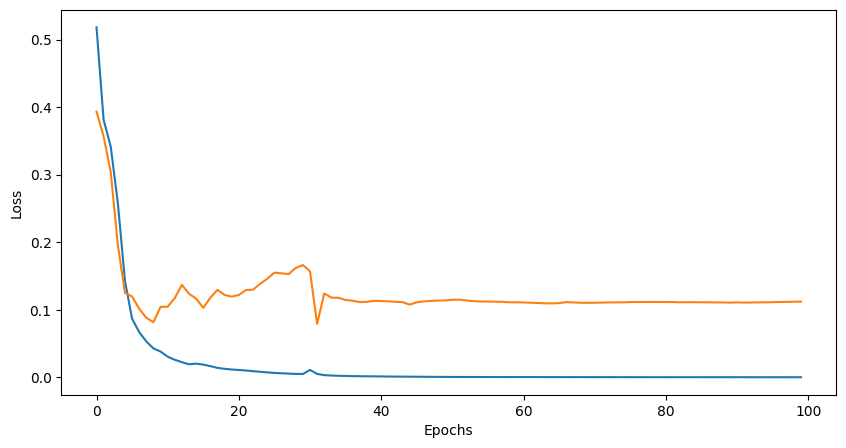

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')  


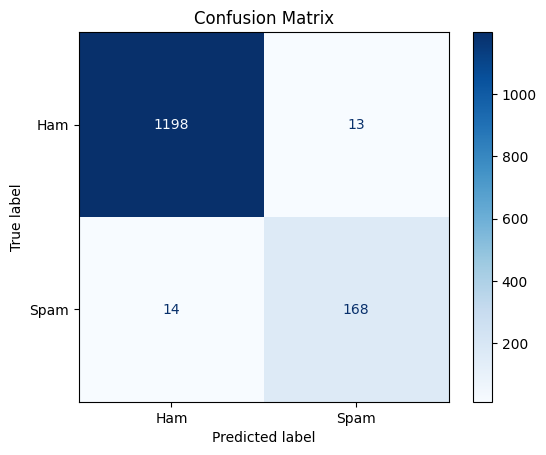

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from the model
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in dg.generate_test(batch_size=BATCH_SIZE):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device).float()
        outputs = model(X_batch)
        predictions = (torch.sigmoid(outputs) > 0.5).int()
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

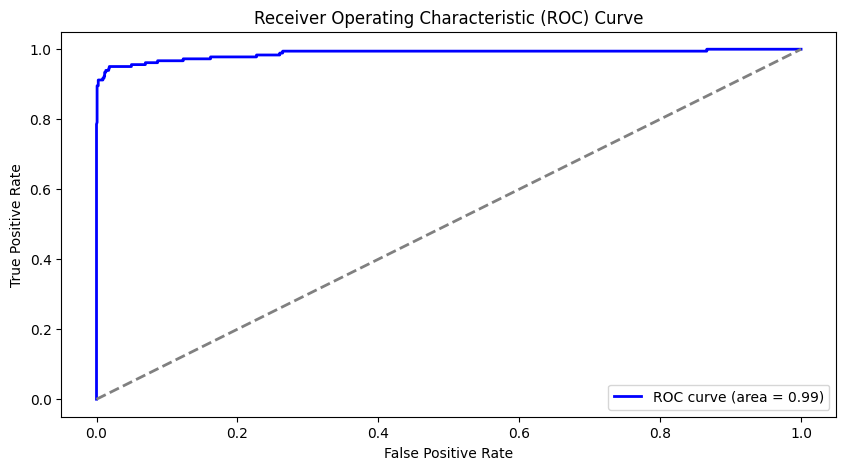

In [25]:
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

# Get predictions and true labels
model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for X_batch, y_batch in dg.generate_test(batch_size=BATCH_SIZE):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device).float()
        outputs = model(X_batch)
        y_true.extend(y_batch.cpu().numpy())
        y_scores.extend(torch.sigmoid(outputs).cpu().numpy())

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()